In [1]:
# Script 1: Generate ANSYS data using LHS
import numpy as np
from scipy.stats import qmc
import pandas as pd

np.random.seed(42)
n_points = 300

t_min = 0.10        # mm
t_max = 1.58        # mm
q_min = 25000.0     # W/m2
q_max = 120000.0    # W/m2
Tinf_min = 25.0
Tinf_max = 40.0

sampler = qmc.LatinHypercube(d=3, seed=42, optimization="random-cd")
sample = sampler.random(n_points)

# SCALING — CONSISTENT WITH BOUNDS
t    = t_min + sample[:,0] * (t_max - t_min)
qpp  = q_min + sample[:,1] * (q_max - q_min)
Tinf = Tinf_min + sample[:,2] * (Tinf_max - Tinf_min)

df = pd.DataFrame({
    'ID':         np.arange(1, n_points+1),
    't_mm':       np.round(t, 4),
    'qpp_Wm2':    np.round(qpp, 0).astype(int),
    'Tinf_C':     np.round(Tinf, 2)
})

# Verification
def gap(t): return (80.0 - 50*t) / 49
min_gap = gap(df['t_mm'].max())
max_gap = gap(df['t_mm'].min())

df.to_csv('ansys_input_300.csv', index=False)
print(f"Data saved to 'ansys_input_300.csv'")
print(f"t range      : {df['t_mm'].min():.4f} – {df['t_mm'].max():.4f} mm")
print(f"q'' range    : {df['qpp_Wm2'].min()} – {df['qpp_Wm2'].max()} W/m²")
print(f"T∞ range     : {df['Tinf_C'].min()} – {df['Tinf_C'].max()} °C")
print(f"Fin gap range: {min_gap:.4f} mm (min) → {max_gap:.4f} mm (max)")


Data saved to 'ansys_input_300.csv'
t range      : 0.1001 – 1.5767 mm
q'' range    : 25311 – 119812 W/m²
T∞ range     : 25.02 – 39.97 °C
Fin gap range: 0.0238 mm (min) → 1.5305 mm (max)


Surrogate Model R²: 0.99999

===== RBDO FINAL OUTPUT =====
Optimal fin thickness    : 1.5431 mm
Heat sink mass (unit d) : 2.5152 kg
Reliability index (β)   : 2.3264
Probability of success  : 99.00%
T_ALLOW constraint      : 129.30 °C


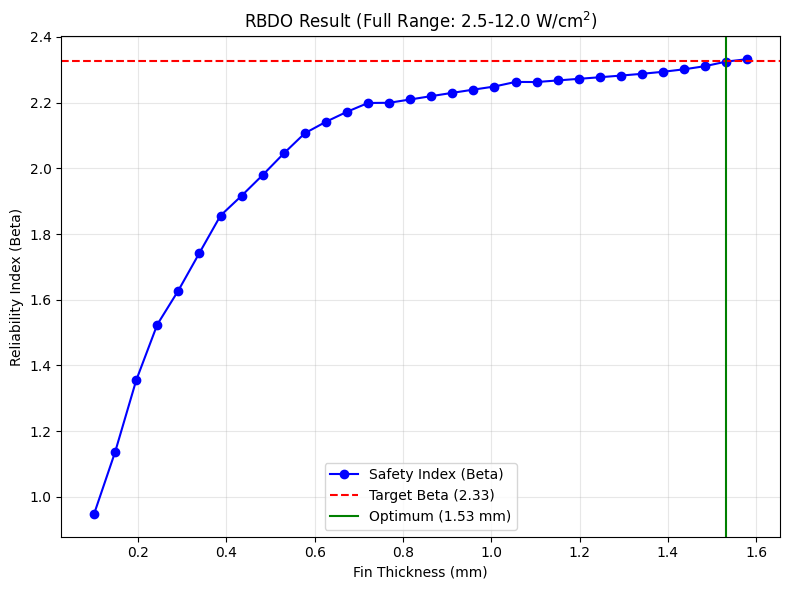

In [2]:
# Script 2: Training and Optimization

import numpy as np
import pandas as pd
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm, uniform
from scipy.optimize import brentq
import matplotlib.pyplot as plt

# Load ANSYS data
df = pd.read_csv('Data.csv', skiprows=6)
data = df.rename(columns={'P2':'t_mm', 'P15':'Tinf_C', 'P18':'qpp_Wm2', 'P17':'T_max'})
data['q_wcm2'] = data['qpp_Wm2'] / 10000.0

X = data[['t_mm', 'q_wcm2', 'Tinf_C']].values
Y = data['T_max'].values

# Normalize inputs
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train surrogate
ann = MLPRegressor(hidden_layer_sizes=(24,24), activation='relu',
                   solver='lbfgs', max_iter=10000, random_state=42)
ann.fit(X_scaled, Y)
print(f'Surrogate Model R²: {ann.score(X_scaled, Y):.5f}')

# Heat sink geometry
W_BASE, H_BASE, H_FIN, N_FINS, RHO, DEPTH = 0.08, 0.002, 0.01, 50, 2700.0, 1.0

# Uncertainty model
Q_MIN, Q_MAX = 2.5, 12.0
MU_T, SIGMA_T = 33.0, 4.0
TF_MIN, TF_MAX = 0.10, 1.58

REL_TARGET = 0.99
BETA_TARGET = norm.ppf(REL_TARGET)

def transform_u_to_x(u):
    u_q, u_t = u[0], u[1]
    phi_u = norm.cdf(u_q)
    phi_u = np.clip(phi_u, 1e-9, 1-1e-9)
    x_q = uniform.ppf(phi_u, loc=Q_MIN, scale=Q_MAX-Q_MIN)
    x_t = MU_T + u_t * SIGMA_T
    return x_q, x_t

def limit_state(t_val, u, limit_temp):
    x_q, x_t = transform_u_to_x(u)
    x_in = np.array([[t_val, x_q, x_t]])
    return limit_temp - ann.predict(scaler.transform(x_in))[0]

def get_gradient(t_val, u, limit_temp):
    h = 1e-4
    grad = np.zeros(2)
    g0 = limit_state(t_val, u, limit_temp)
    grad[0] = (limit_state(t_val, u + [h,0], limit_temp) - g0)/h
    grad[1] = (limit_state(t_val, u + [0,h], limit_temp) - g0)/h
    return grad

def run_hl_rf(t_val, limit_temp):
    u = np.zeros(2)
    for _ in range(20):
        g = limit_state(t_val, u, limit_temp)
        grad = get_gradient(t_val, u, limit_temp)
        norm_grad = np.linalg.norm(grad)
        if norm_grad < 1e-6: break
        b = np.dot(grad, u)
        u_next = (b - g)/(norm_grad**2) * grad
        if np.linalg.norm(u_next - u) < 1e-4:
            u = u_next
            break
        u = u_next
    beta = np.linalg.norm(u)
    if limit_state(t_val, np.zeros(2), limit_temp) < 0: beta = -beta
    return beta

def compute_mass(t_mm):
    t_m = t_mm / 1000.0
    return RHO * (W_BASE * H_BASE + N_FINS * H_FIN * t_m) * DEPTH

def feasibility_func(temp):
    return run_hl_rf(TF_MAX, temp) - BETA_TARGET
T_ALLOW = np.ceil(brentq(feasibility_func, 100, 160, xtol=1e-2) * 10) / 10.0

def objective_func(t):
    return run_hl_rf(t, T_ALLOW) - BETA_TARGET
opt_tf = brentq(objective_func, TF_MIN, TF_MAX, xtol=1e-4)
beta_opt = run_hl_rf(opt_tf, T_ALLOW)
mass_opt = compute_mass(opt_tf)
prob_opt = norm.cdf(beta_opt)

print("\n===== RBDO FINAL OUTPUT =====")
print(f"Optimal fin thickness    : {opt_tf:.4f} mm")
print(f"Heat sink mass (unit d) : {mass_opt:.4f} kg")
print(f"Reliability index (β)   : {beta_opt:.4f}")
print(f"Probability of success  : {prob_opt*100:.2f}%")
print(f"T_ALLOW constraint      : {T_ALLOW:.2f} °C")

# ----- Reliability vs. Thickness Plot -----
t_sweep = np.linspace(TF_MIN, TF_MAX, 32)
betas = [run_hl_rf(t, T_ALLOW) for t in t_sweep]
opt_idx = np.argmin(np.abs(np.array(betas) - BETA_TARGET))
opt_tf_plot = t_sweep[opt_idx]

plt.figure(figsize=(8, 6))
plt.plot(t_sweep, betas, 'b-o', label='Safety Index (Beta)')
plt.axhline(BETA_TARGET, color='r', linestyle='--', label=f'Target Beta ({BETA_TARGET:.2f})')
plt.axvline(opt_tf_plot, color='g', linestyle='-', label=f'Optimum ({opt_tf_plot:.2f} mm)')
plt.xlabel('Fin Thickness (mm)')
plt.ylabel('Reliability Index (Beta)')
plt.title(f'RBDO Result (Full Range: {Q_MIN}-{Q_MAX} W/cm$^2$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('rbdo_beta_vs_thickness.png', dpi=200)
plt.show()

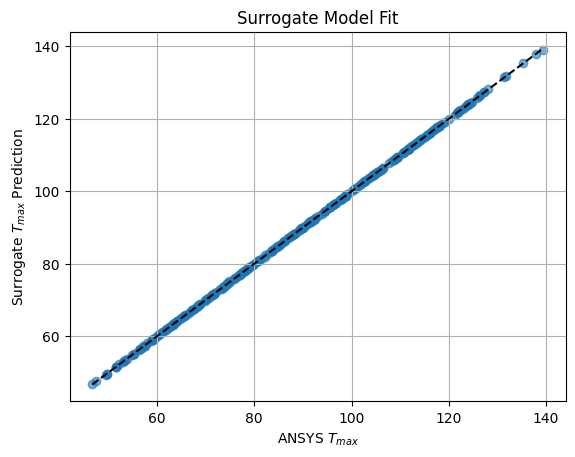

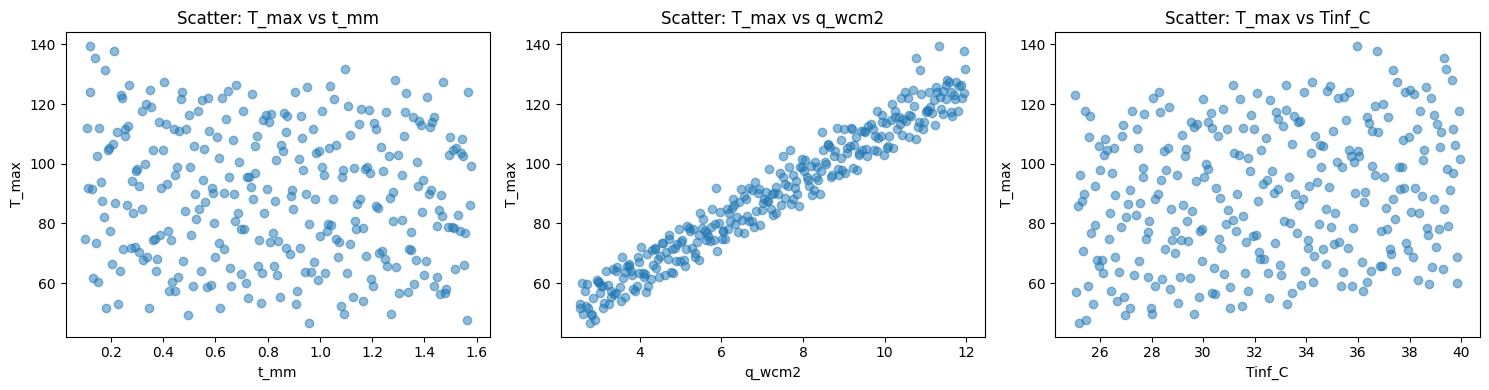

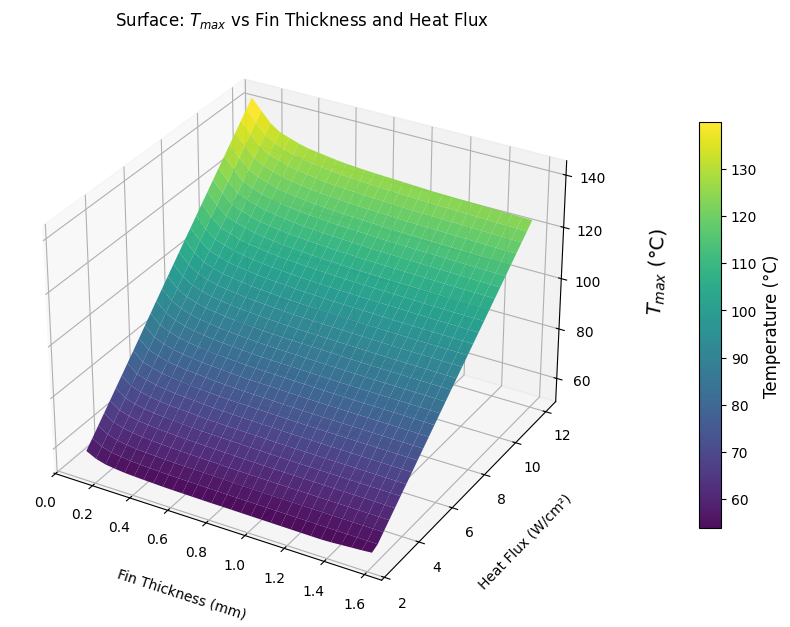


===== ANOVA =====
Source                    SS      df              MS              F0
Regression         147963.34       9        16440.37        17562.40
Residual              271.47     290            0.94
Total              148234.82     298


In [5]:
# Script 3: Post-processes Data.csv and trained ANN surrogate

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D

# Load ANSYS Data
df = pd.read_csv('Data.csv', skiprows=6)
data = df.rename(columns={'P2':'t_mm', 'P15':'Tinf_C', 'P18':'qpp_Wm2', 'P17':'T_max'})
data['q_wcm2'] = data['qpp_Wm2'] / 10000.0
X = data[['t_mm', 'q_wcm2', 'Tinf_C']].values
Y = data['T_max'].values

# Surrogate Model Fit Plot
plt.figure()
plt.scatter(Y, ann.predict(X_scaled), alpha=0.6)
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'k--')
plt.xlabel('ANSYS $T_{max}$')
plt.ylabel('Surrogate $T_{max}$ Prediction')
plt.title('Surrogate Model Fit')
plt.grid(True)
plt.show()

# Scatter Plots for Each Input
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, name in enumerate(['t_mm', 'q_wcm2', 'Tinf_C']):
    axes[i].scatter(data[name], data['T_max'], alpha=0.5)
    axes[i].set_xlabel(name)
    axes[i].set_ylabel('T_max')
    axes[i].set_title(f'Scatter: T_max vs {name}')
plt.tight_layout()
plt.show()

# Surface Plot
t_grid = np.linspace(data['t_mm'].min(), data['t_mm'].max(), 30)
q_grid = np.linspace(data['q_wcm2'].min(), data['q_wcm2'].max(), 30)
Tinf_fixed = 33.0
Tmax_surf = np.zeros((30, 30))
for i, t in enumerate(t_grid):
    for j, q in enumerate(q_grid):
        X_surf = np.array([[t, q, Tinf_fixed]])
        Tmax_surf[i, j] = ann.predict(scaler.transform(X_surf))[0]
T_T, Q_T = np.meshgrid(t_grid, q_grid, indexing='ij')

fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(T_T, Q_T, Tmax_surf, cmap='viridis', edgecolor='none', alpha=0.95)
ax.set_xlabel('Fin Thickness (mm)', labelpad=14)
ax.set_ylabel('Heat Flux (W/cm²)', labelpad=14)
ax.set_zlabel(r'$T_{max}$ (°C)', fontsize=14, labelpad=22)
ax.set_title(r'Surface: $T_{max}$ vs Fin Thickness and Heat Flux')
fig.subplots_adjust(left=0.12, right=0.93, bottom=0.10, top=0.92)

cbar = fig.colorbar(surf, ax=ax, shrink=0.55, aspect=18, pad=0.13)
cbar.set_label('Temperature (°C)', fontsize=12)

plt.show()

# ANOVA Table
n = X_poly.shape[0]
k = X_poly.shape[1]
Y_bar = np.mean(Y)
SSt = np.sum((Y - Y_bar)**2)
SSr = np.sum((Y_fitted - Y_bar)**2)
SSe = np.sum((Y - Y_fitted)**2)

dfr = k
dfe = n - k
dft = n - 1

MSr = SSr/dfr
MSe = SSe/dfe
F0  = MSr/MSe

print("\n===== ANOVA =====")
print(f"{'Source':<12}{'SS':>16}{'df':>8}{'MS':>16}{'F0':>16}")
print(f"{'Regression':<12}{SSr:16.2f}{dfr:8}{MSr:16.2f}{F0:16.2f}")
print(f"{'Residual':<12}{SSe:16.2f}{dfe:8}{MSe:16.2f}")
print(f"{'Total':<12}{SSt:16.2f}{dft:8}")


In [11]:
# Comparison between Deterministic and Stochastic Design

test_q_wcm2 = Q_MAX
test_Tinf_C = MU_T

print(f"Test Case Conditions:\n  Heat Flux (q_wcm2): {test_q_wcm2:.2f} W/cm²\n  Ambient Temp (Tinf_C): {test_Tinf_C:.2f} °C\n")

# Function to predict T_max for a given fin thickness and test conditions
def predict_t_max_for_test_case(t_val, q_val, Tinf_val):
    x_in = np.array([[t_val, q_val, Tinf_val]])
    return ann.predict(scaler.transform(x_in))[0]

# Deterministic Optimum
predicted_T_max_deterministic = predict_t_max_for_test_case(
    opt_tf_deterministic, test_q_wcm2, test_Tinf_C
)

deterministic_result = "Fail" if predicted_T_max_deterministic > T_ALLOW else "Pass"

print(f"Deterministic Design (t = {opt_tf_deterministic:.4f} mm) under Worst-Case:\n  Predicted T_max: {predicted_T_max_deterministic:.2f} °C (Allowed: {T_ALLOW:.2f} °C)\n  Result: {deterministic_result}\n")

#  Stochastic Optimum
predicted_T_max_stochastic = predict_t_max_for_test_case(
    opt_tf, test_q_wcm2, test_Tinf_C
)

stochastic_result = "Fail" if predicted_T_max_stochastic > T_ALLOW else "Pass"

print(f"Stochastic Design (t = {opt_tf:.4f} mm) under Worst-Case:\n  Predicted T_max: {predicted_T_max_stochastic:.2f} °C (Allowed: {T_ALLOW:.2f} °C)\n  Result: {stochastic_result}\n")

Test Case Conditions:
  Heat Flux (q_wcm2): 12.00 W/cm²
  Ambient Temp (Tinf_C): 33.00 °C

Deterministic Design (t = 0.1000 mm) under Worst-Case:
  Predicted T_max: 143.72 °C (Allowed: 129.30 °C)
  Result: Fail

Stochastic Design (t = 1.5431 mm) under Worst-Case:
  Predicted T_max: 124.57 °C (Allowed: 129.30 °C)
  Result: Pass

